In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.6f}'.format)

In [4]:
data = pd.read_csv("DrDoS_NTP.csv")

In [5]:
data.columns = data.columns.str.strip()

In [7]:
data.shape

(1217007, 88)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1217007 entries, 0 to 1217006
Data columns (total 88 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Unnamed: 0                   1217007 non-null  int64  
 1   Flow ID                      1217007 non-null  object 
 2   Source IP                    1217007 non-null  object 
 3   Source Port                  1217007 non-null  int64  
 4   Destination IP               1217007 non-null  object 
 5   Destination Port             1217007 non-null  int64  
 6   Protocol                     1217007 non-null  int64  
 7   Timestamp                    1217007 non-null  object 
 8   Flow Duration                1217007 non-null  int64  
 9   Total Fwd Packets            1217007 non-null  int64  
 10  Total Backward Packets       1217007 non-null  int64  
 11  Total Length of Fwd Packets  1217007 non-null  float64
 12  Total Length of Bwd Packets  1217007 non-n

In [20]:
data.isna().sum().sum()

np.int64(31)

In [21]:
data.select_dtypes(include=['object'])

,Flow ID,Source IP,Destination IP,Timestamp,SimillarHTTP,Label
0,172.16.0.5-192.168.50.1-60675-80-6,172.16.0.5,192.168.50.1,2018-12-01 09:17:11.183810,205.174.165.72/c.php,DrDoS_NTP
1,172.16.0.5-192.168.50.1-60676-80-6,172.16.0.5,192.168.50.1,2018-12-01 09:17:11.205636,0,DrDoS_NTP
2,192.168.50.7-65.55.163.78-50458-443-6,65.55.163.78,192.168.50.7,2018-12-01 09:17:12.634569,0,BENIGN
3,192.168.50.7-65.55.163.78-50465-443-6,65.55.163.78,192.168.50.7,2018-12-01 09:17:13.458370,0,BENIGN
4,192.168.50.253-224.0.0.5-0-0-0,192.168.50.253,224.0.0.5,2018-12-01 09:17:13.470913,0,BENIGN
...,...,...,...,...,...,...
1217002,172.16.0.5-192.168.50.1-634-63125-17,172.16.0.5,192.168.50.1,2018-12-01 10:51:39.600556,0,DrDoS_NTP
1217003,172.16.0.5-192.168.50.1-634-12431-17,172.16.0.5,192.168.50.1,2018-12-01 10:51:39.635018,0,DrDoS_NTP
1217004,172.16.0.5-192.168.50.1-634-881-17,172.16.0.5,192.168.50.1,2018-12-01 10:51:39.685553,0,DrDoS_NTP
1217005,172.16.0.5-192.168.50.1-634-7051-17,172.16.0.5,192.168.50.1,2018-12-01 10:51:39.721301,0,DrDoS_NTP


In [22]:
data = data.drop(columns=["Flow ID","Source IP","Destination IP"])

In [24]:
data = data.drop(columns=["Unnamed: 0","Source Port","Destination Port","Protocol"])

In [26]:
data_int = data.select_dtypes(include=['int64'])

<Axes: >

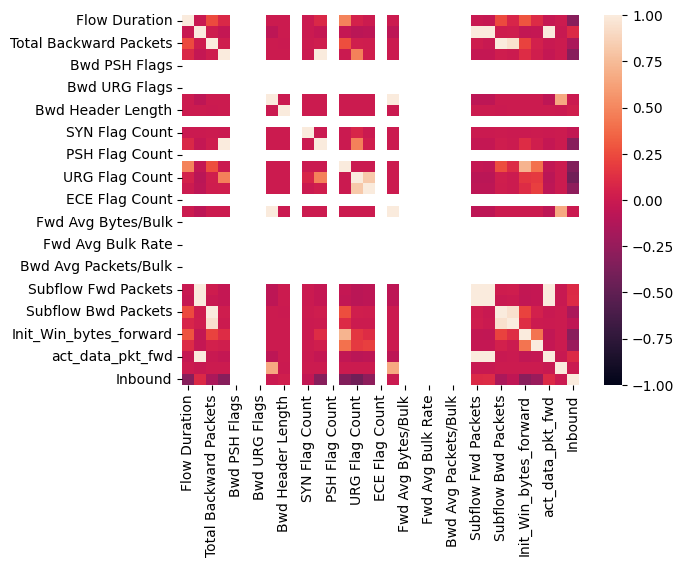

In [31]:
sns.heatmap(data_int.corr(),vmin=-1,vmax=1)

In [32]:
drop_int_columns = [
    "Total Backward Packets",
    "Subflow Bwd Packets",
    "PSH Flag Count",
    "URG Flag Count",
    "ECE Flag Count",
    "Init_Win_bytes_forward",
    "Inbound",
    "Bwd URG Flags",
    "Bwd PSH Flags",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Packets/Bulk",   
    "Bwd Header Length"
]

In [33]:
data_int = data_int.drop(columns=drop_int_columns)

<Axes: >

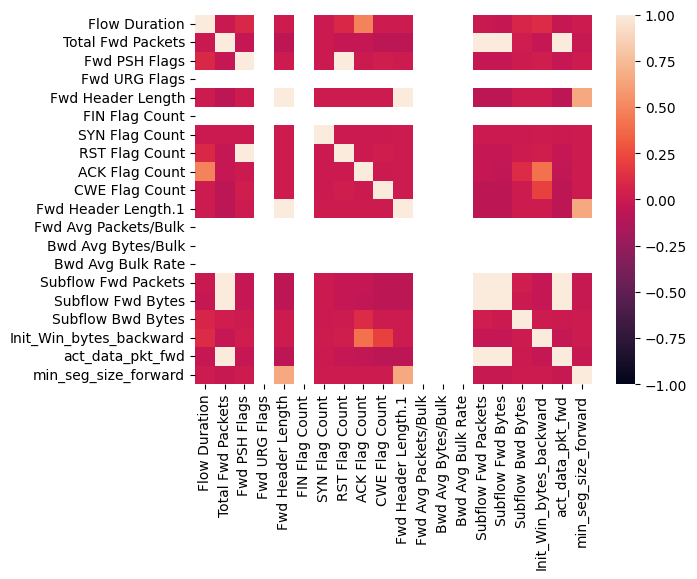

In [35]:
sns.heatmap(data_int.corr(),vmax=1,vmin=-1)

In [41]:
drop_columns2 = [
    "Fwd Header Length.1",
    "Subflow Fwd Packets",
    "Subflow Fwd Bytes",
    "Init_Win_bytes_backward",
    "FIN Flag Count",
    "RST Flag Count",
    "CWE Flag Count",
    "Fwd PSH Flags",
    "Fwd URG Flags",
    "Fwd Avg Packets/Bulk",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Bulk Rate",
    "min_seg_size_forward"
]

In [42]:
data_int = data_int.drop(columns=drop_columns2)

In [46]:
data_int = data_int.drop(columns="Total Fwd Packets")

<Axes: >

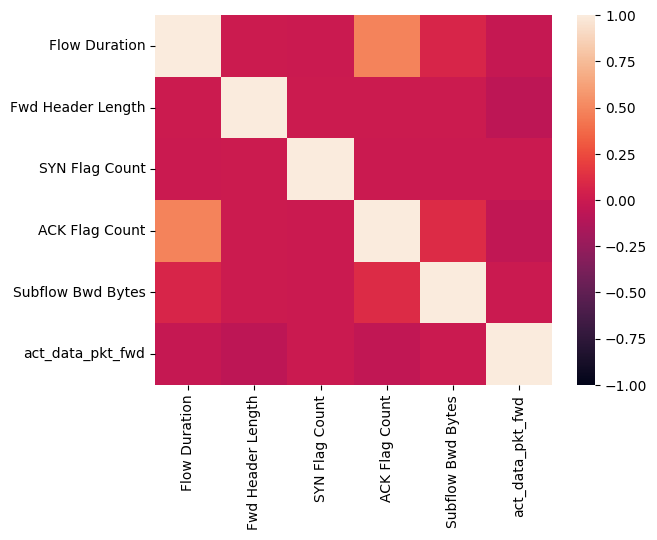

In [47]:
sns.heatmap(data_int.corr(),vmax=1,vmin=-1)

In [48]:
data_float = data.select_dtypes(include=['float64'])

<Axes: >

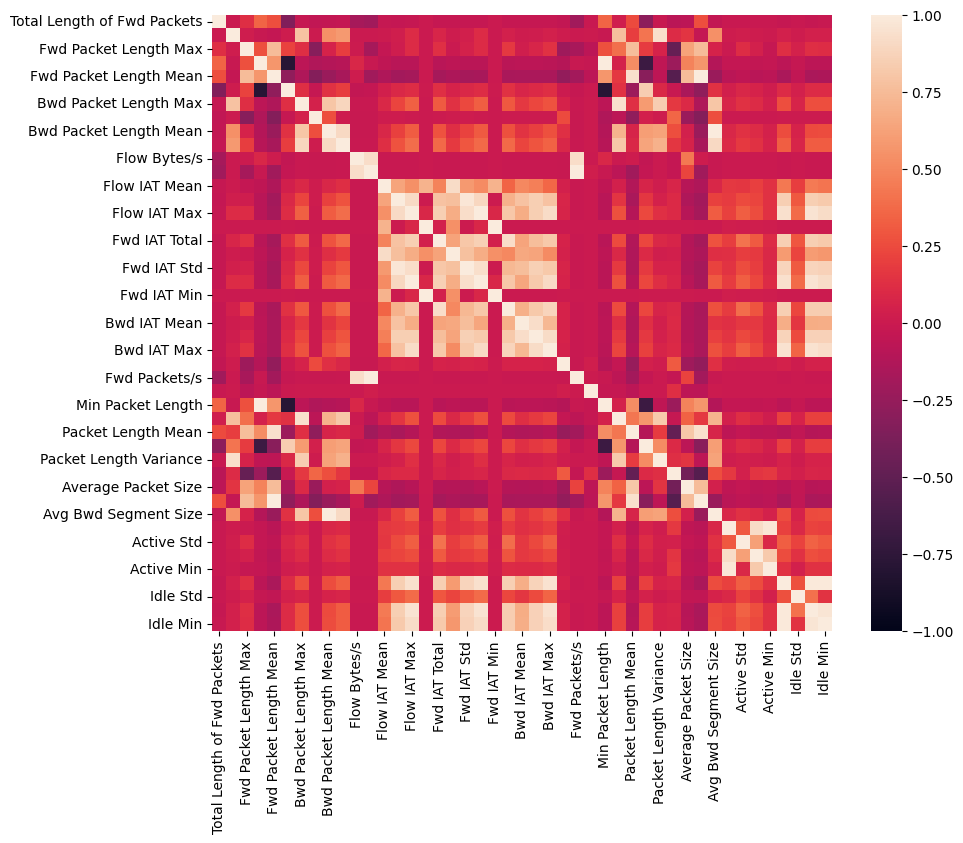

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [51]:
drop_columns3 = [
    "Fwd Packet Length Max",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Average Packet Size",
    "Avg Bwd Segment Size",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Fwd IAT Total",
    "Fwd IAT Std",
    "Fwd IAT Min",
    "Bwd IAT Mean",
    "Bwd IAT Max",
    "Active Std",
    "Active Min",
    "Idle Std",
    "Total Length of Fwd Packets",
    "Fwd Packets/s",
    "Packet Length Variance"
]

In [52]:
data_float = data_float.drop(columns=drop_columns3)

<Axes: >

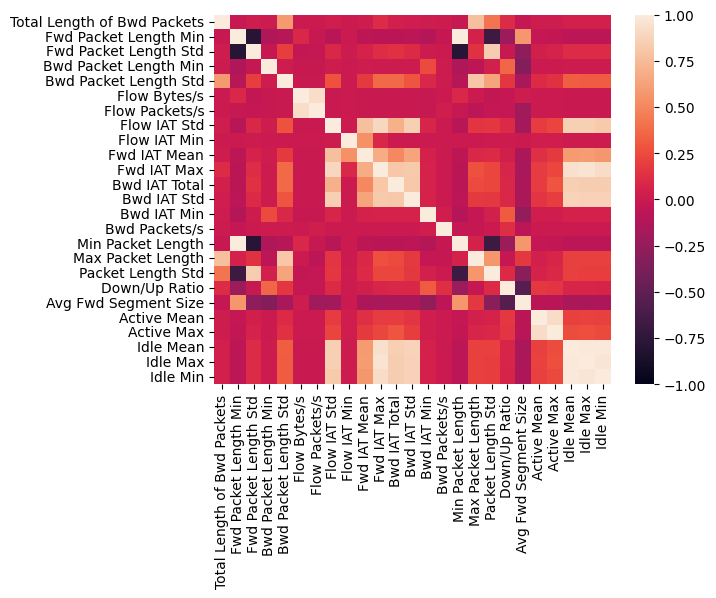

In [53]:
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [56]:
drop_columns4 = [
    "Fwd Packet Length Min",
    "Fwd Packet Length Std",
    "Bwd Packet Length Min",
    "Bwd Packet Length Std",
    "Max Packet Length",
    "Packet Length Std",
    "Avg Fwd Segment Size",
    "Flow IAT Std",
    "Flow IAT Min",
    "Fwd IAT Mean",
    "Fwd IAT Max",
    "Bwd IAT Total",
    "Bwd IAT Std",
    "Active Mean",
    "Active Max",
    "Idle Max",
    "Total Length of Bwd Packets",
    "Bwd Packets/s",
   "Down/Up Ratio"
]

In [57]:
data_float = data_float.drop(columns=drop_columns4)

<Axes: >

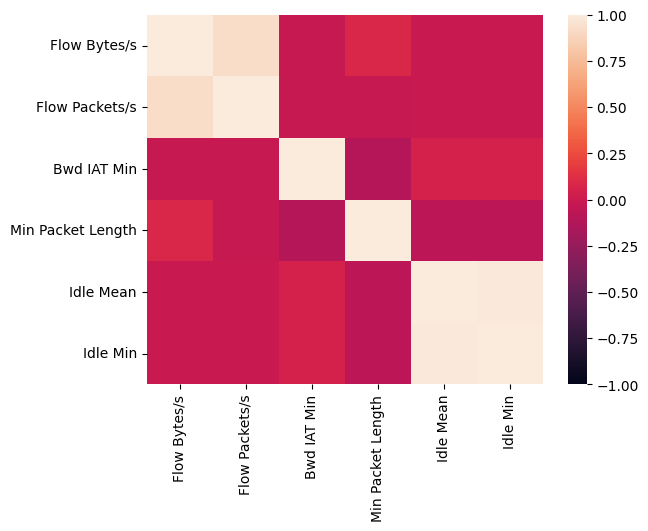

In [59]:
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [60]:
data_float = data_float.drop(columns=["Flow Packets/s","Idle Mean"])

<Axes: >

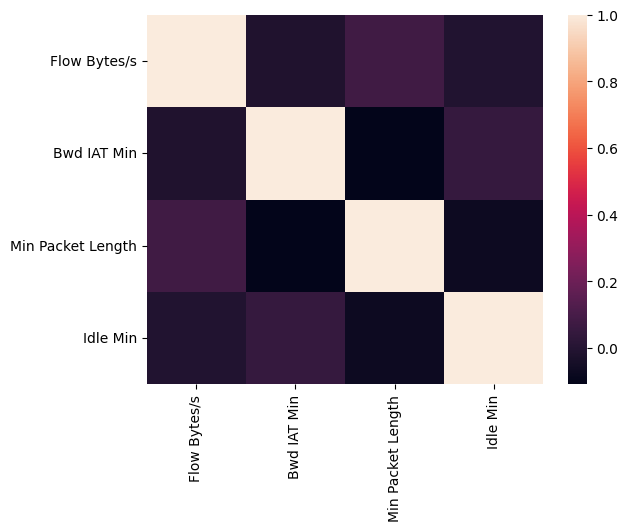

In [62]:
sns.heatmap(data_float.corr())

In [67]:
data['Label'].value_counts()

Label
DrDoS_NTP    1202642
BENIGN         14365
Name: count, dtype: int64

In [68]:
data['SimillarHTTP'].value_counts()

SimillarHTTP
0                                                                                     1015808
0                                                                                      200039
205.174.165.72/c.php                                                                      461
ocsp.pki.goog/GTSGIAG3                                                                     68
ocsp.digicert.com/                                                                         67
                                                                                       ...   
205.174.165.72/c.php?ip=10.73.91.150                                                        1
205.174.165.72/c.php?ip=10.40.4.8                                                           1
talebi.ca/wp-content/plugins/wpdiscuz/utils/captcha/captcha.php?key=c5c029ef1bbdf9          1
talebi.ca/wp-content/plugins/wpdiscuz/utils/captcha/captcha.php?key=c5c029ef1bc09a          1
205.174.165.72/c.php?ip=192.168.8.3            

In [74]:
data_obj = data.select_dtypes(include="object")

In [75]:
data_obj["SimilarHTTP_flag"] = (data_obj["SimillarHTTP"] != "0").astype(int)

In [76]:
data_obj["SimilarHTTP_flag"].value_counts()

SimilarHTTP_flag
1    1016968
0     200039
Name: count, dtype: int64

In [78]:
data_obj = data_obj.drop(columns='SimillarHTTP')

In [79]:
data_obj

,Timestamp,Label,SimilarHTTP_flag
0,2018-12-01 09:17:11.183810,DrDoS_NTP,1
1,2018-12-01 09:17:11.205636,DrDoS_NTP,0
2,2018-12-01 09:17:12.634569,BENIGN,0
3,2018-12-01 09:17:13.458370,BENIGN,0
4,2018-12-01 09:17:13.470913,BENIGN,0
...,...,...,...
1217002,2018-12-01 10:51:39.600556,DrDoS_NTP,0
1217003,2018-12-01 10:51:39.635018,DrDoS_NTP,0
1217004,2018-12-01 10:51:39.685553,DrDoS_NTP,0
1217005,2018-12-01 10:51:39.721301,DrDoS_NTP,0


In [80]:
data_obj = data_obj[["Timestamp", "SimilarHTTP_flag", "Label"]]

In [83]:
obj_cols, float_cols, int_cols = list(np.array(data_obj.columns)), list(np.array(data_float.columns)), list(np.array(data_int.columns))

In [87]:
final_cols = float_cols+int_cols+obj_cols

In [136]:
final_data = data[final_cols]

<Axes: >

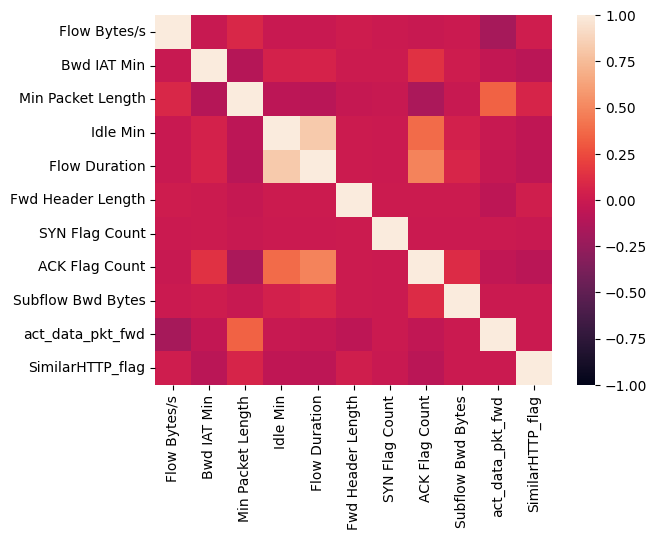

In [137]:
sns.heatmap(final_data.select_dtypes(include=['float64','int64']).corr(),vmax=1,vmin=-1)

In [138]:
final_data["Timestamp"] = pd.to_datetime(final_data["Timestamp"])

In [139]:
final_data["Timestamp"] = final_data["Timestamp"].dt.strftime("%y-%m-%d %H:%M:%S")

In [140]:
final_data.describe()

,Flow Bytes/s,Bwd IAT Min,Min Packet Length,Idle Min,Flow Duration,Fwd Header Length,SYN Flag Count,ACK Flag Count,Subflow Bwd Bytes,act_data_pkt_fwd,SimilarHTTP_flag
count,1216976.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000
mean,inf,0.028365,347.137413,39200.786387,131402.916050,-447162842.650593,0.000049,0.003279,132.472416,62.110291,0.835630
std,NaN,0.648165,132.163709,1380248.127200,3442526.227711,7599155317.475525,0.007021,0.057172,20979.887156,63.682826,0.370611
min,0.000000,0.000000,0.000000,0.000000,0.000000,-212543795000.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4547568.601106,0.000000,224.000000,0.000000,350.000000,-4.000000,0.000000,0.000000,0.000000,13.000000,1.000000
50%,18044464.618954,0.000000,440.000000,0.000000,1001.000000,120.000000,0.000000,0.000000,0.000000,37.000000,1.000000
75%,58210116.731518,0.000000,440.000000,0.000000,4296.000000,812.000000,0.000000,0.000000,0.000000,93.000000,1.000000
max,inf,258.000000,1460.000000,114745523.000000,119999877.000000,88000.000000,1.000000,1.000000,8829488.000000,399.000000,1.000000


In [141]:
final_data.replace([np.inf, -np.inf], 0, inplace=True)

In [142]:
final_data.describe()

,Flow Bytes/s,Bwd IAT Min,Min Packet Length,Idle Min,Flow Duration,Fwd Header Length,SYN Flag Count,ACK Flag Count,Subflow Bwd Bytes,act_data_pkt_fwd,SimilarHTTP_flag
count,1216976.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000,1217007.000000
mean,63601532.572109,0.028365,347.137413,39200.786387,131402.916050,-447162842.650593,0.000049,0.003279,132.472416,62.110291,0.835630
std,158952643.590245,0.648165,132.163709,1380248.127200,3442526.227711,7599155317.475525,0.007021,0.057172,20979.887156,63.682826,0.370611
min,0.000000,0.000000,0.000000,0.000000,0.000000,-212543795000.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4375455.677376,0.000000,224.000000,0.000000,350.000000,-4.000000,0.000000,0.000000,0.000000,13.000000,1.000000
50%,17600000.000000,0.000000,440.000000,0.000000,1001.000000,120.000000,0.000000,0.000000,0.000000,37.000000,1.000000
75%,56712871.287129,0.000000,440.000000,0.000000,4296.000000,812.000000,0.000000,0.000000,0.000000,93.000000,1.000000
max,2592000000.000000,258.000000,1460.000000,114745523.000000,119999877.000000,88000.000000,1.000000,1.000000,8829488.000000,399.000000,1.000000


In [143]:
final_data.isna().sum().sum()

np.int64(31)

In [144]:
final_data = final_data.dropna(subset=['Flow Bytes/s'])

In [145]:
final_data['Flow Bytes/s'] = pd.to_numeric(final_data['Flow Bytes/s'], errors='coerce')

In [146]:
final_data['Flow Bytes/s'].fillna(0, inplace=True)

In [147]:
final_data.isna().sum().sum()

np.int64(0)

In [148]:
len(final_data)

1216976

In [150]:
final_data = final_data.set_index("Timestamp")

In [152]:
final_data.to_csv("Processed_DrDoS_NTP.csv",index=True)

In [157]:
final_data['Label'].value_counts()

Label
DrDoS_NTP    1202639
BENIGN         14337
Name: count, dtype: int64

In [158]:
final_data.shape

(1216976, 12)